In [1]:
from collections import Counter
import re

In [2]:
import os

def load_documents(dataset_path):
    documents = {}
    for filename in os.listdir(dataset_path):
        if filename.endswith('.txt'):
            with open(os.path.join(dataset_path, filename), 'r', encoding='latin-1') as file:
                documents[filename] = file.read()
    return documents

In [3]:
dataset_path = r"D:\\graduate\\information retrieval\\assignment1\\dataset"

In [4]:
import nltk

In [5]:
import re
import inflect # usage - convert integers to text (e.g., 5 to five)
from nltk.corpus import stopwords

def to_lowercase(words):
    #"""Convert all characters to lowercase from list of tokenized words"""
    new_words = []
    for word in words:
        new_word = word.lower()
        new_words.append(new_word)
    return new_words

def remove_punctuation(words):
    # Remove punctuation from list of tokenized words
    new_words = []
    for word in words:
        new_word = re.sub(r'[^\w\s]', '', word) 
        # remove all characters stored in "word" except for alphanumeric character and whitespace 
        # caret ^ at beginning => negates the pattern 
        # \w: an alphanumeric characters => (letters and digits) and underscores => [a-zA-Z0-9_]
        # \s: a whitespace character
        if new_word != '':
            new_words.append(new_word)
    return new_words

def replace_numbers(words):
    # inflect - replace all interger occurrences in list of tokenized words with textual representation
    p = inflect.engine()
    new_words = []
    for word in words:
        if word.isdigit():
            new_word = p.number_to_words(word)
            new_words.append(new_word)
        else:
            new_words.append(word)
    return new_words

def remove_stopwords(words):
    """Remove stop words from list of tokenized words"""
    new_words = []
    for word in words:
        if word not in stopwords.words('english'):
            new_words.append(word)
    return new_words

def normalize(words):
    words = to_lowercase(words)
    words = remove_punctuation(words)
    words = replace_numbers(words)
    words = remove_stopwords(words)
    return words

In [6]:


documents_dict = load_documents(dataset_path)
processed_docs = {}

for file_name, content in documents_dict.items():

    tokens = nltk.word_tokenize(content)
    tokens = normalize(tokens)
    tokens = remove_stopwords(tokens)

    processed_docs[file_name] = tokens

# controlled vocabulary

### define controlled vocabulary

In [7]:
# Equivalent Terms

from nltk.corpus import wordnet

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonyms.add(lemma.name().replace('_', ' '))
    return list(synonyms)


print(f"Covid-19 : {get_synonyms('covid')}")
print(f"Property : {get_synonyms('Property')}")
print(f"VTL : {get_synonyms('VTL')}")
print(f"Omicron : {get_synonyms('Omicron')}")

Covid-19 : []
Property : ['property', 'holding', 'attribute', 'belongings', 'prop', 'dimension', 'place']
VTL : []
Omicron : ['omicron']


In [8]:
from collections import Counter

def extract_pure_data_variants(target_word, processed_docs, n=3):

    phrases = []
    target_lower = target_word.lower()

    for filename, tokens in processed_docs.items():   

        for i, w in enumerate(tokens):

            if w.lower() == target_lower:

                if i >= n:
                    before_phrase = " ".join(tokens[i-n:i+1])
                    phrases.append(before_phrase)

                if i <= len(tokens) - (n+1):
                    after_phrase = " ".join(tokens[i:i+n+1])
                    phrases.append(after_phrase)

    return Counter(phrases).most_common(5)

In [9]:
extract_pure_data_variants("Omicron", processed_docs)

[('tested preliminarily positive omicron', 14),
 ('booster shots amid omicron', 11),
 ('amid rapid spread omicron', 10),
 ('omicron cases singapore far', 9),
 ('amid potential covid19 omicron', 9)]

## combine the two ways to define controlled vocabulary

In [10]:
controlled_vocabulary = {
    "Covid-19": ["covid-19", "covid", "coronavirus", "pandemic", "sars-cov-2"],
    "Property": get_synonyms("property") + ["real estate", "housing market"], 
    "VTL": ["vtl", "vaccinated travel lane", "travel lanes", "land vtl"], 
    "Omicron": ["omicron", "variant", "strain","covid19"]
}

In [11]:
import pandas as pd

In [12]:
def controlled_search(doc_tokens, query_id):

    tokens = [t.lower() for t in doc_tokens]

    has_covid = any(term in tokens for term in controlled_vocabulary["Covid-19"])
    has_property = any(term in tokens for term in controlled_vocabulary["Property"])
    has_vtl = any(term in tokens for term in controlled_vocabulary["VTL"])
    has_omicron = any(term in tokens for term in controlled_vocabulary["Omicron"])


    if query_id == 1:
        return has_covid
    elif query_id == 2:
        return has_covid and has_property
    elif query_id == 3:
        return has_covid and has_vtl
    elif query_id == 4:
        return has_covid and has_omicron
    elif query_id == 5:
        return has_covid and not has_omicron


query_descriptions = [
    "Covid-19", 
    "Covid-19 and Property", 
    "Covid-19 and VTL", 
    "Covid-19 and Omicron", 
    "Covid-19 not Omicron"
]

final_results = []
for i, desc in enumerate(query_descriptions, 1):

    count = sum(1 for doc_content in processed_docs.values() if controlled_search(doc_content, i))
    final_results.append({"Query ID": i, "Topic": desc, "Relevant Documents Found": count})


results_df = pd.DataFrame(final_results)
print(results_df)

   Query ID                  Topic  Relevant Documents Found
0         1               Covid-19                       291
1         2  Covid-19 and Property                        82
2         3       Covid-19 and VTL                        79
3         4   Covid-19 and Omicron                       276
4         5   Covid-19 not Omicron                        15


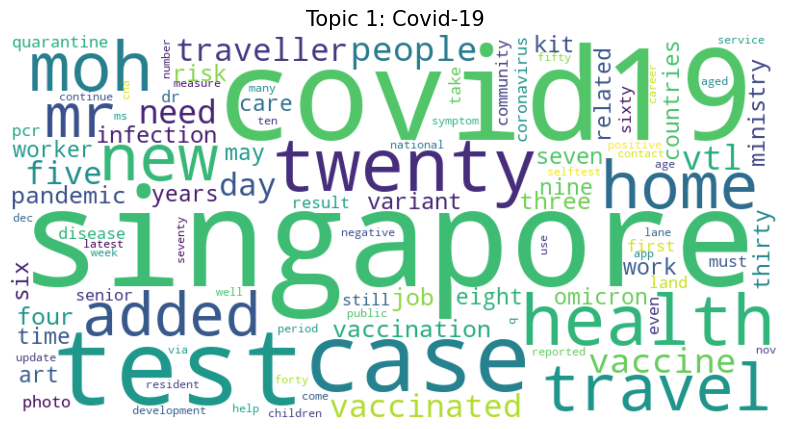

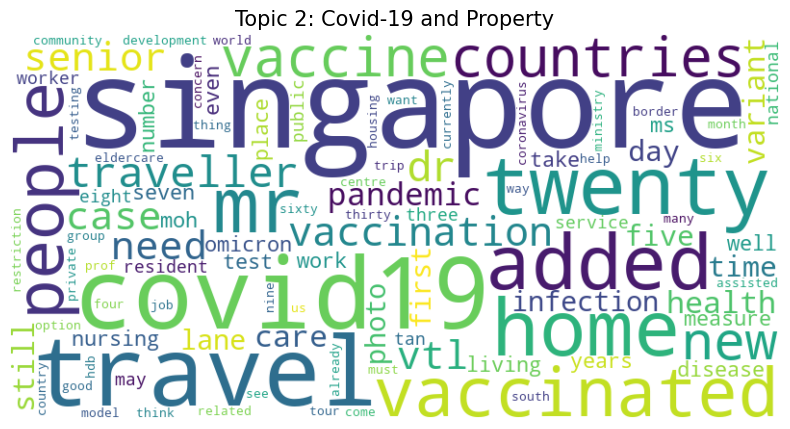

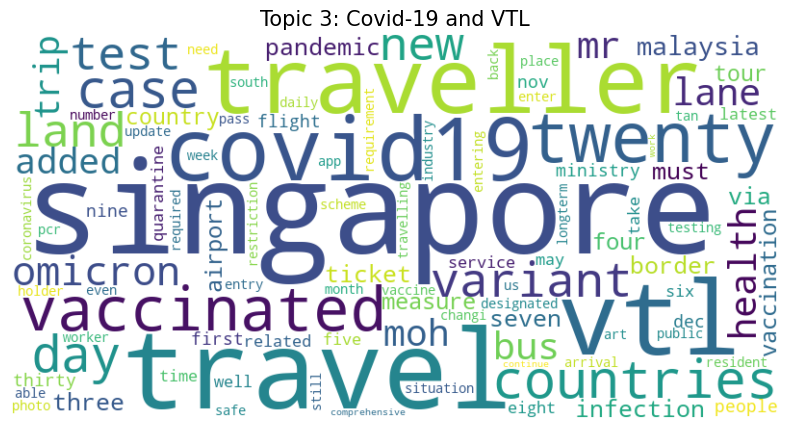

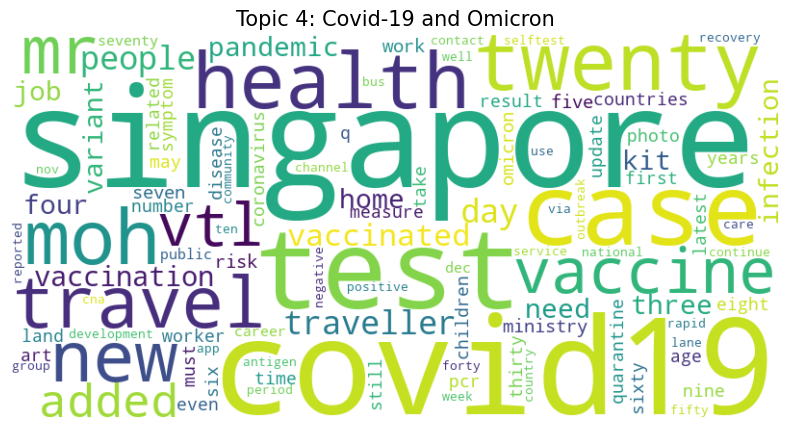

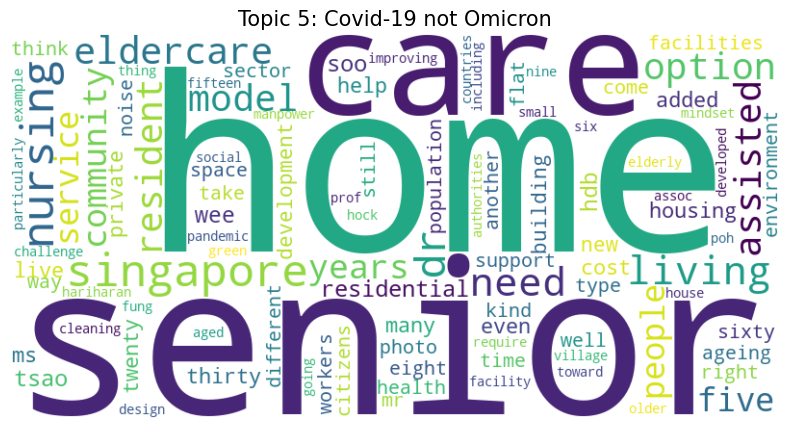

In [22]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

my_custom_words = {"per", "cent", "thousand", "said", "two", "one", "hundred", "last", "year"}
all_stopwords = STOPWORDS.union(my_custom_words)

for i, desc in enumerate(query_descriptions, 1):
    
    all_words_for_topic = []
    
    for doc_content in processed_docs.values():
        if controlled_search(doc_content, i):
            all_words_for_topic.extend(doc_content)
    
    text_data = " ".join(all_words_for_topic)

    wc = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        max_words=100,
        stopwords=all_stopwords, 
        collocations=False       
    ).generate(text_data)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Topic {i}: {desc}", fontsize=15)
    plt.axis('off')
    plt.show()

# free text search

In [38]:
import nltk


document_ids = list(processed_docs.keys())
documents = [processed_docs[idx] for idx in document_ids]

tc = nltk.TextCollection(documents)

query = [
    "Covid-19", 
    "Covid-19 and Property", 
    "Covid-19 and VTL", 
    "Covid-19 and Omicron", 
    "Covid-19 not Omicron"
]

for q_text in query:
    query_tokens = [t.lower() for t in nltk.word_tokenize(q_text)]
    
    output_text = [] 


    for i, idx in enumerate(document_ids):
        score = 0
        doc_tokens = documents[i]

        if "and" in q_text.lower():
            if not (query_tokens[0] in doc_tokens and query_tokens[2] in doc_tokens):
                continue 

        if "not" in q_text.lower():
            if not (query_tokens[0] in doc_tokens and query_tokens[2] not in doc_tokens):
                continue
        
        for term in query_tokens:
            score += tc.tf_idf(term.lower(), doc_tokens)
        
        if score > 0:
            output_text.append({
                'score': score, 
                'title': processed_docs[idx]
            })

    output_text = sorted(output_text, key=lambda p: p['score'], reverse=True)


    for result in output_text[:5]:
        print(f"Score: {result['score']:.4f} | Title: {result['title']}")
    print("\n") 

# improve the retrieval systems

In [ ]:
controlled_vocabulary = {
    "Covid-19": ["covid-19", "covid", "coronavirus", "pandemic", "covid19"],
    "Property": get_synonyms("property") + ["real estate", "housing market"], 
    "VTL": ["vtl", "vaccinated travel lane", "travel lanes", "land vtl"], 
    "Omicron": ["omicron", "variant", "strain","covid19"]
}

In [48]:
from nltk.text import TextCollection

document_ids = list(processed_docs.keys())
documents = [processed_docs[idx] for idx in document_ids]

tc = TextCollection(documents)


def preprocess(text):
    tokens = nltk.word_tokenize(text)
    tokens = normalize(tokens)
    tokens = remove_stopwords(tokens)
    return tokens

queries = [
    "Covid-19",
    "Covid-19 and Property",
    "Covid-19 and VTL",
    "Covid-19 and Omicron",
    "Covid-19 not Omicron"
]

for q_text in queries:

    print(f"\nQuery: {q_text}")

    tokens = q_text.split()

    has_and = "and" in q_text.lower()
    has_not = "not" in q_text.lower()

    base_terms = [t for t in tokens if t.lower() not in ["and", "not"]]


    expanded_query = {}
    for term in base_terms:
        if term in controlled_vocabulary:
            expanded = []
            for t in controlled_vocabulary[term]:
                expanded.extend(preprocess(t))
            expanded_query[term] = expanded
        else:
            expanded_query[term] = preprocess(term)

    output_text = []


    for i, idx in enumerate(document_ids):

        doc_tokens = documents[i]
        score = 0


        if has_and:
            condition = all(
                any(word in doc_tokens for word in expanded_query[term])
                for term in expanded_query
            )
            if not condition:
                continue

        if has_not:
            term1 = base_terms[0]
            term2 = base_terms[1]

            cond1 = any(word in doc_tokens for word in expanded_query[term1])
            cond2 = any(word in doc_tokens for word in expanded_query[term2])

            if not (cond1 and not cond2):
                continue

        for term in expanded_query:
            for word in expanded_query[term]:
                score += tc.tf_idf(word, doc_tokens)

        if score > 0:
            output_text.append({
                "score": score,
                "doc_id": idx
            })

    output_text = sorted(output_text, key=lambda x: x["score"], reverse=True)

    for result in output_text[:5]:
        print(f"Score: {result['score']:.4f} | Doc ID: {result['doc_id']}")


Query: Covid-19
Score: 0.0463 | Doc ID: 20211205_23_SGPContent.txt
Score: 0.0463 | Doc ID: 20211206_25_SGPContent.txt
Score: 0.0452 | Doc ID: 20211124_14_SGPContent.txt
Score: 0.0414 | Doc ID: 20211128_28_SGPContent.txt
Score: 0.0355 | Doc ID: 20211212_17_SGPContent.txt

Query: Covid-19 and Property
Score: 0.1371 | Doc ID: 20211216_14_SGPContent.txt
Score: 0.1274 | Doc ID: 20211211_4_SGPContent.txt
Score: 0.1274 | Doc ID: 20211216_4_SGPContent.txt
Score: 0.0571 | Doc ID: 20211204_14_SGPContent.txt
Score: 0.0571 | Doc ID: 20211205_6_SGPContent.txt

Query: Covid-19 and VTL
Score: 0.3326 | Doc ID: 20211127_21_SGPContent.txt
Score: 0.3326 | Doc ID: 20211128_30_SGPContent.txt
Score: 0.3326 | Doc ID: 20211203_62_SGPContent.txt
Score: 0.3280 | Doc ID: 20211129_18_SGPContent.txt
Score: 0.3280 | Doc ID: 20211203_47_SGPContent.txt

Query: Covid-19 and Omicron
Score: 0.1666 | Doc ID: 20211206_14_SGPContent.txt
Score: 0.1598 | Doc ID: 20211205_23_SGPContent.txt
Score: 0.1598 | Doc ID: 20211206_25